In [14]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In this code we import the data from the mit bih data, and then we plot the graph for the first 10 seconds of the record number 100

Sampling frequency:  360
Signal Shape:  (650000, 2)


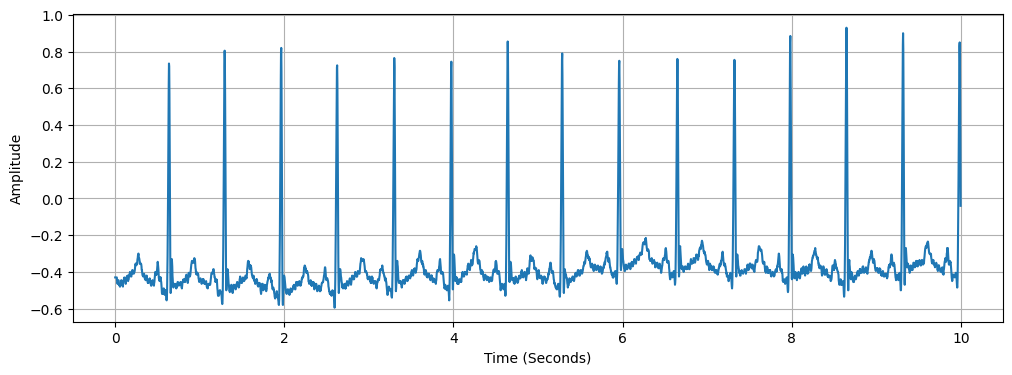

In [15]:
record=wfdb.rdrecord('205', pn_dir='mitdb')
signal=record.p_signal
fs=record.fs

print("Sampling frequency: ",fs)
print("Signal Shape: ",signal.shape)

ecg_signal=signal[:, 0]

time=np.arange(len(ecg_signal))/fs

plt.figure(figsize=(12,4))
plt.plot(time[:10*fs], ecg_signal[:10*fs])
plt.xlabel("Time (Seconds)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.savefig("../results/raw_ecg_plot.png", dpi=300)
plt.show()

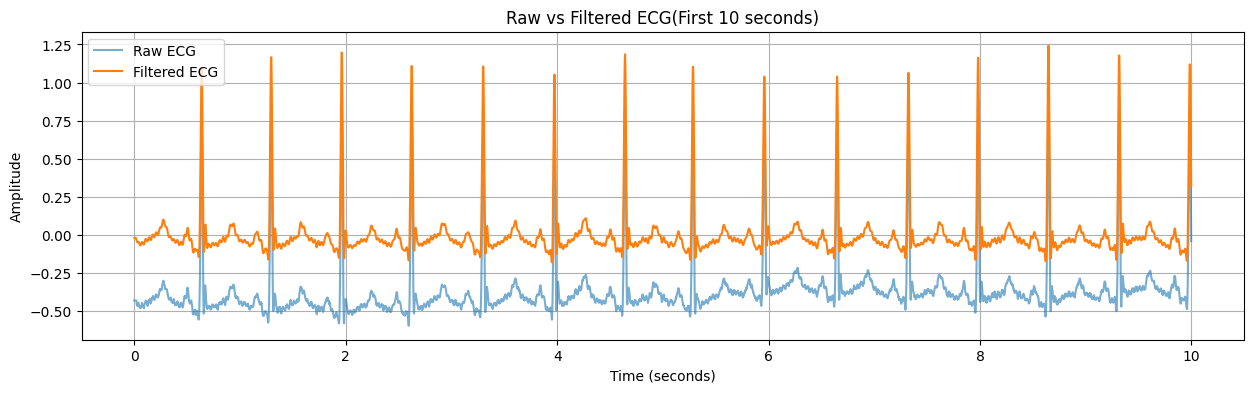

In [16]:
lowcut=0.5
highcut=40.0
order=4

nyquist=0.5*fs 
low=lowcut/nyquist
high=highcut/nyquist

b, a=butter(order,[low, high], btype='band')
filtered_ecg = filtfilt(b, a, ecg_signal)

plt.figure(figsize=(15,4))
plt.plot(time[:10*fs], ecg_signal[:10*fs], label='Raw ECG', alpha=0.6)
plt.plot(time[:10*fs], filtered_ecg[:10*fs], label='Filtered ECG')
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Raw vs Filtered ECG(First 10 seconds)")
plt.legend()
plt.grid(True)
plt.savefig("../results/rawvsfiltered_ecg_plot.png", dpi=300)
plt.show()

In this graph, we plotted the raw ecg and the filtered ecg, in the filtered ecg we use filtfilt which forward backwrad filtering, which removes noise twice without shifting the phase of the signal 

Nyquist frequency=half of the sampling frequency

In [17]:
from scipy.signal import find_peaks
peaks, properties = find_peaks(
    filtered_ecg,
    distance=int(0.6 * fs),
    height=0.3 * np.max(filtered_ecg)
)

r_peak_time=peaks/fs

rr_intervals=np.diff(r_peak_time)

print("First 10 RR intervals (seconds)")
print(np.round(rr_intervals[:10], 3))
print("\n------------------------\n")
print("R-peak time(seconds)")
for t in r_peak_time[:10]:
    print(round(t,3))

First 10 RR intervals (seconds)
[0.658 0.667 0.661 0.678 0.675 0.667 0.642 0.675 0.689 0.675]

------------------------

R-peak time(seconds)
0.636
1.294
1.961
2.622
3.3
3.975
4.642
5.283
5.958
6.647


In this we find exact time of R peak and the RR interval of first 10 seconds 

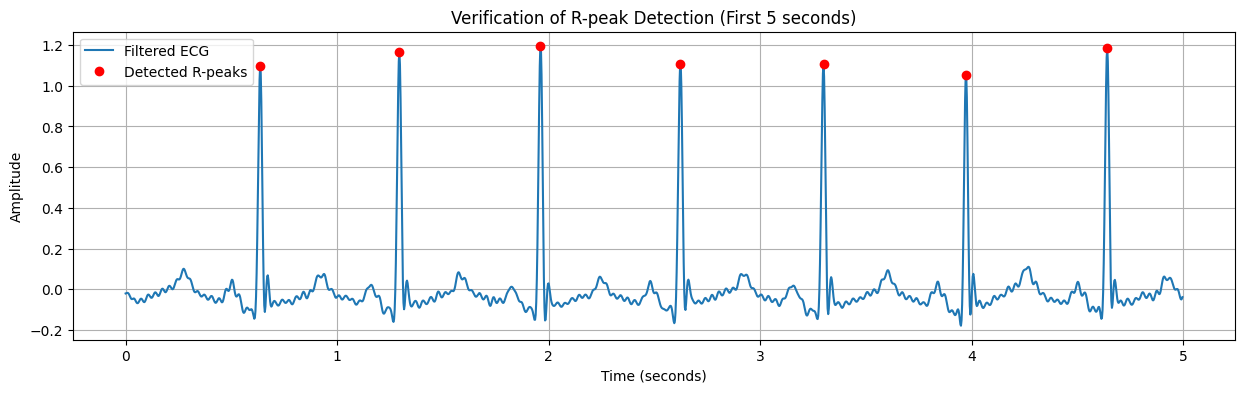

In [18]:
# Limit to first 5 seconds
limit = int(5 * fs)

# Select only peaks within first 5 seconds
peaks_5s = peaks[peaks < limit]

plt.figure(figsize=(15,4))
plt.plot(time[:limit], filtered_ecg[:limit], label="Filtered ECG")
plt.plot(time[peaks_5s], filtered_ecg[peaks_5s], 'ro', label="Detected R-peaks")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Verification of R-peak Detection (First 5 seconds)")
plt.legend()
plt.grid(True)
plt.savefig("../results/r_peak_detection.png", dpi=300)
plt.show()


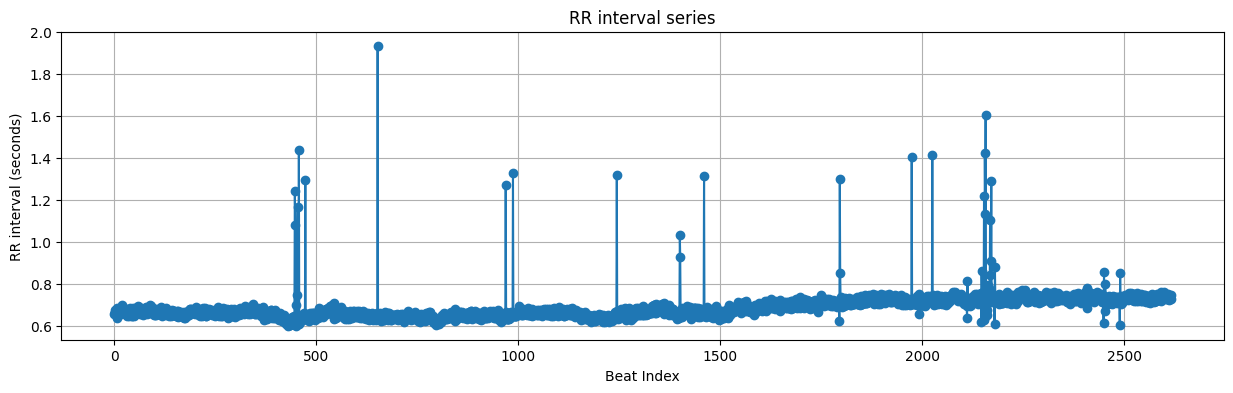

In [20]:

plt.figure(figsize=(15, 4))
plt.plot(rr_intervals, marker='o')
plt.xlabel("Beat Index")
plt.ylabel("RR interval (seconds)")
plt.title("RR interval series")
plt.grid(True)
plt.plot()
plt.savefig("../results/rr_interval.png", dpi=300)

RR Interval Analysis
The RR interval series shows a stable rhythm with most intervals between 0.7 and 0.9 seconds, indicating a normal heart rate.
Occasional larger intervals are attributed to detection variability and were handled using physiologically plausible bounds before feature extraction.

In [21]:
# Remove physiologically implausible RR intervals
rr_intervals_clean = rr_intervals[
    (rr_intervals > 0.4) & (rr_intervals < 1.5)
]

print("RR count before cleaning:", len(rr_intervals))
print("RR count after cleaning:", len(rr_intervals_clean))


RR count before cleaning: 2617
RR count after cleaning: 2615


In [22]:
heart_rate=60/rr_intervals_clean

features={
    "mean_RR":np.mean(rr_intervals_clean),
    "std_RR":np.std(rr_intervals_clean),
    "min_RR":np.min(rr_intervals_clean),
    "max_RR":np.max(rr_intervals_clean),
    "mean_HR":np.mean(heart_rate),
    "std_HR":np.std(heart_rate)
}

for k, v in features.items():
    print(f"{k}: {round(v, 3)}")

mean_RR: 0.689
std_RR: 0.062
min_RR: 0.603
max_RR: 1.442
mean_HR: 87.62
std_HR: 5.824


In [23]:
df=pd.DataFrame([features])
df

,mean_RR,std_RR,min_RR,max_RR,mean_HR,std_HR
0,0.688713,0.062234,0.602778,1.441667,87.620303,5.824337


In [24]:
from collections import Counter

def get_record_label_symbol(record_id):
    ann = wfdb.rdann(record_id, 'atr', pn_dir='mitdb')
    symbols = ann.symbol

    mapping = {
        'N': 'N',
        'L': 'L',
        'R': 'R',
        'A': 'A',
        'a': 'A',
        'J': 'A',
        'V': 'V',
        'E': 'V',
        'F': 'F'
    }

    mapped = [mapping[s] for s in symbols if s in mapping]

    if len(mapped) == 0:
        return 'N'

    return Counter(mapped).most_common(1)[0][0]


def extract_features(record_id):
    record = wfdb.rdrecord(record_id, pn_dir='mitdb')
    signal = record.p_signal
    fs = record.fs

    ecg_signal = signal[:, 0]

    nyquist = 0.5 * fs
    low = 0.5 / nyquist
    high = 40 / nyquist
    b, a = butter(4, [low, high], btype='band')
    filtered_ecg = filtfilt(b, a, ecg_signal)

    max_val = np.max(filtered_ecg)
    peaks, _ = find_peaks(
        filtered_ecg,
        distance=int(0.6 * fs),
        height=0.3 * max_val
    )

    r_peak_time = peaks / fs
    rr_intervals = np.diff(r_peak_time)

    rr_intervals_clean = rr_intervals[
        (rr_intervals > 0.4) & (rr_intervals < 1.5)
    ]

    if len(rr_intervals_clean) == 0:
        return None

    heart_rate = 60 / rr_intervals_clean

    label_symbol = get_record_label_symbol(record_id)

    features = {
        "record_id": record_id,
        "mean_RR": np.mean(rr_intervals_clean),
        "std_RR": np.std(rr_intervals_clean),
        "mean_HR": np.mean(heart_rate),
        "std_HR": np.std(heart_rate),
        "label_symbol": label_symbol
    }

    return features

In [25]:
def get_record_label_symbol(record_id):
    ann=wfdb.rdann(record_id, 'atr', pn_dir='mitdb')
    symbols=ann.symbol

    for sym in ['V','A','L','R','F']:
        if sym in symbols:
            return sym
    return 'N'

In [26]:
records = [
'100','101','102','103','104','105','106','107','108','109',
'111','112','113','114','115','116','117','118','119','121',
'122','123','124','200','201','202','203','205','207','208',
'209','210','212','213','214','215','217','219','220','221',
'222','223','228','230','231','232','233','234'
]

data=[]

for rid in records:
    try:
        feats=extract_features(rid)
        if feats is not None:
            data.append(feats)
        print(f"{rid} done")
    except Exception as e:
        print(f"{rid} failed:", e)

df=pd.DataFrame(data)
df

symbol_meaning = {
    'N': 'Normal',
    'V': 'Ventricular ectopic beat (PVC)',
    'A': 'Atrial premature beat',
    'L': 'Left bundle branch block',
    'R': 'Right bundle branch block',
    'F': 'Fusion beat'
}

df['label_name'] = df['label_symbol'].map(symbol_meaning)

symbol_to_num = {
    'N': 0,
    'V': 1,
    'A': 2,
    'L': 3,
    'R': 4,
    'F': 5
}

df['label_num'] = df['label_symbol'].map(symbol_to_num)

df


100 done
101 done
102 done
103 done
104 done
105 done
106 done
107 done
108 done
109 done
111 done
112 done
113 done
114 done
115 done
116 done
117 done
118 done
119 done
121 done
122 done
123 done
124 done
200 done
201 done
202 done
203 done
205 done
207 done
208 done
209 done
210 done
212 done
213 done
214 done
215 done
217 done
219 done
220 done
221 done
222 done
223 done
228 done
230 done
231 done
232 done
233 done
234 done


,record_id,mean_RR,std_RR,mean_HR,std_HR,label_symbol,label_name,label_num
0,100,0.798551,0.059192,75.470104,4.706580,V,Ventricular ectopic beat (PVC),1
1,101,0.968020,0.067395,62.304046,4.651768,A,Atrial premature beat,2
2,102,0.826761,0.032775,72.670245,2.539378,V,Ventricular ectopic beat (PVC),1
3,103,0.866701,0.047262,69.439762,3.919194,A,Atrial premature beat,2
4,104,0.811241,0.041090,74.133140,3.485289,V,Ventricular ectopic beat (PVC),1
5,105,0.726008,0.106967,83.835466,8.301026,V,Ventricular ectopic beat (PVC),1
6,106,0.987771,0.156750,62.178194,9.267172,V,Ventricular ectopic beat (PVC),1
7,107,0.860663,0.083744,70.160800,4.763865,V,Ventricular ectopic beat (PVC),1
8,108,1.065223,0.090139,56.736781,5.005797,V,Ventricular ectopic beat (PVC),1
9,109,0.724271,0.088732,83.565398,6.157279,V,Ventricular ectopic beat (PVC),1


In [27]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   record_id     48 non-null     object 
 1   mean_RR       48 non-null     float64
 2   std_RR        48 non-null     float64
 3   mean_HR       48 non-null     float64
 4   std_HR        48 non-null     float64
 5   label_symbol  48 non-null     object 
 6   label_name    48 non-null     object 
 7   label_num     48 non-null     int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 3.1+ KB


,mean_RR,std_RR,mean_HR,std_HR,label_num
count,48.000000,48.000000,48.000000,48.000000,48.000000
mean,0.890716,0.126073,70.405449,8.891714,1.145833
std,0.131378,0.070681,10.172516,5.040029,0.618495
min,0.662594,0.023844,50.861129,2.539378,0.000000
25%,0.800912,0.071102,62.529893,4.749544,1.000000
50%,0.871708,0.107849,70.637147,8.207553,1.000000
75%,0.974056,0.186751,77.527779,12.164971,1.000000
max,1.191028,0.270790,90.888053,20.754703,4.000000


In [28]:
df['label_symbol'].value_counts()

label_symbol
V    37
A     7
N     3
R     1
Name: count, dtype: int64

In [29]:
X=df[['mean_RR', 'std_RR', 'mean_HR', 'std_HR']]
y=df['label_num']

In [30]:
# Remove classes that have fewer than 2 samples
counts = df['label_num'].value_counts()
valid_classes = counts[counts >= 2].index

df = df[df['label_num'].isin(valid_classes)]

# Create features and labels again after filtering
X = df[['mean_RR', 'std_RR', 'mean_HR', 'std_HR']]
y = df['label_num']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Train model
model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


              precision    recall  f1-score   support

           N       0.00      0.00      0.00         1
           V       0.79      0.92      0.85        12
           A       0.00      0.00      0.00         2

    accuracy                           0.73        15
   macro avg       0.26      0.31      0.28        15
weighted avg       0.63      0.73      0.68        15



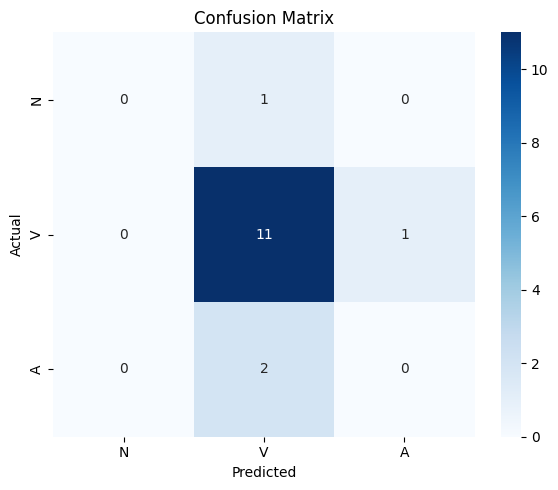

In [31]:
y_pred = model.predict(X_test)

# ===== Classification Report =====
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Use only labels actually present in test/pred
labels = sorted(np.unique(np.concatenate([y_test, y_pred])))
target_names = [k for k, v in symbol_to_num.items() if v in labels]

report = classification_report(
    y_test,
    y_pred,
    labels=labels,
    target_names=target_names,
    zero_division=0
)

print(report)

with open("../results/classification_report.txt", "w") as f:
    f.write(report)

# ===== Confusion Matrix =====
import seaborn as sns

cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()

# Save image
plt.savefig("confusion_matrix.png", dpi=300)

plt.show()

In [36]:
%pip install seaborn


  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: C:\Users\ARYA\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


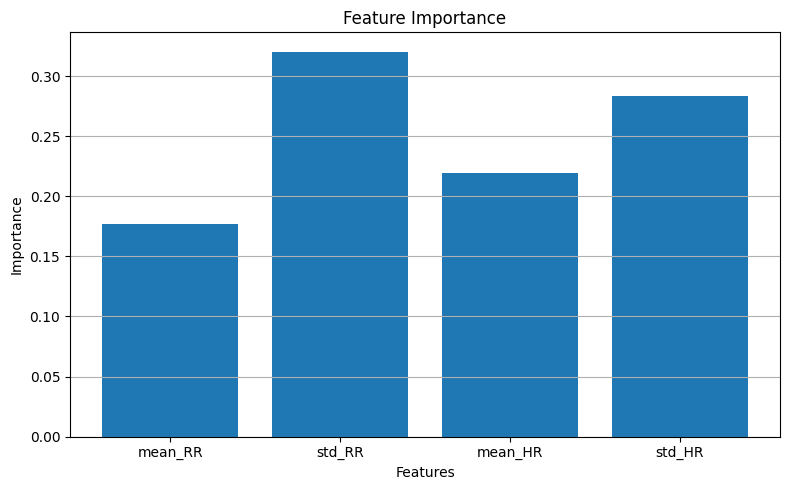

mean_RR: 0.177
std_RR: 0.320
mean_HR: 0.219
std_HR: 0.283


In [37]:
importances = model.feature_importances_

plt.figure(figsize=(8,5))
plt.bar(X.columns, importances)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.grid(axis='y')
plt.tight_layout()
plt.savefig("../results/feature_importance.png", dpi=300)
plt.show()

for name, val in zip(X.columns, importances):
    print(f"{name}: {val:.3f}")

In [38]:
import joblib

joblib.dump(model, "random_forest_model.pkl")


['random_forest_model.pkl']

In [39]:
def predict_record(record_id):
    features = extract_features(record_id)

    if features is None:
        return "Not enough valid data"

    import pandas as pd

    X_new = pd.DataFrame([{
        'mean_RR': features['mean_RR'],
        'std_RR': features['std_RR'], 
        'mean_HR': features['mean_HR'],
        'std_HR': features['std_HR']
    }])

    pred = model.predict(X_new)[0]

    label_map = {v: k for k, v in symbol_to_num.items()}

    return label_map[pred]

In [43]:
print(predict_record('109'))
print(predict_record('212'))

V
V


In [44]:
with open("../results/sample_predictions.txt", "w") as f:
    f.write(f"Record 100: {predict_record('100')}\n")
    f.write(f"Record 101: {predict_record('101')}\n")
    f.write(f"Record 105: {predict_record('105')}\n")